## Cell 1 — Installs & Imports

In [ ]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from sklearn.model_selection import KFold, cross_val_predict, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, accuracy_score, f1_score)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print('All imports done ✓')

All imports done ✓


## Cell 2 — Load & Aggregate to System Level (600 rows)

In [ ]:
df = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Original shape:', df.shape)

df_sys = df.groupby('timestep_sec').agg({
    'minute_of_hour':                  'first',
    'system_total_load_kW':            'first',
    'system_total_vehicles':           'first',
    'system_moving_vehicles':          'first',
    'system_charging_vehicles':        'first',
    'system_waiting_vehicles':         'first',
    'system_avg_speed_ms':             'first',
    'system_avg_soc_percent':          'first',
    'system_avg_moving_speed_ms':      'first',
    'system_avg_moving_soc_percent':   'first',
    'system_avg_charging_soc_percent': 'first',
    'system_avg_charging_duration_sec':'first',
    'station_vehicles_charging':       'sum',
    'station_queue_length':            'sum',
    'station_utilization_percent':     'mean',
    'speed_ms':                        'mean',
    'acceleration_ms2':                'mean',
    'soc_percent':                     'mean',
    'energy_consumed_Wh':              'sum',
}).reset_index().sort_values('timestep_sec').reset_index(drop=True)

print('System-level shape:', df_sys.shape)
print('Load range:', df_sys['system_total_load_kW'].min(),
      '–', df_sys['system_total_load_kW'].max(), 'kW')

X = df_sys.drop(columns=['system_total_load_kW', 'timestep_sec'])
y = df_sys['system_total_load_kW']
print('Features:', X.shape[1], '| Samples:', len(X))

Original shape: (34020, 25)
System-level shape: (600, 20)
Load range: 0.0 – 1340.0 kW
Features: 18 | Samples: 600


## Cell 3 — Define Models & KFold

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

COLORS = {
    'Linear Regression': '#2196F3',
    'Decision Tree':     '#009688',
    'Random Forest':     '#FF9800',
    'XGBoost':           '#F44336',
}

models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),

    'Decision Tree':     DecisionTreeRegressor(
                             max_depth=3,
                             min_samples_leaf=25,
                             random_state=42),

    'Random Forest':     RandomForestRegressor(
                             n_estimators=100,
                             max_depth=4,
                             min_samples_leaf=20,
                             random_state=42),

    'XGBoost':           XGBRegressor(
                             n_estimators=300,
                             learning_rate=0.05,
                             max_depth=4,
                             subsample=0.8,
                             colsample_bytree=0.8,
                             reg_lambda=2,
                             random_state=42,
                             verbosity=0),
}
print('Models defined ✓')
print('KFold: n_splits=5, shuffle=True, random_state=42')

Models defined ✓
KFold: n_splits=5, shuffle=True, random_state=42


## Cell 4 — Per-Fold Train vs Test Metrics (Performance + Fit Check)

For each model and each fold we compute **both** train and test scores.
- **Train R²** = how well model fits the training portion of that fold
- **Test R²**  = how well model generalises to the held-out portion
- **Gap** = Train R² − Test R² → near zero = good fit, large positive = overfitting

In [ ]:
fold_results = {}   # stores per-fold train/test metrics for every model

print(f"{'='*80}")
for name, model in models.items():
    tr_r2_list, te_r2_list   = [], []
    tr_mae_list, te_mae_list = [], []
    tr_rmse_list,te_rmse_list= [], []

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)
        tr_pred = model.predict(X_tr)
        te_pred = model.predict(X_te)

        tr_r2_list.append(r2_score(y_tr, tr_pred))
        te_r2_list.append(r2_score(y_te, te_pred))
        tr_mae_list.append(mean_absolute_error(y_tr, tr_pred))
        te_mae_list.append(mean_absolute_error(y_te, te_pred))
        tr_rmse_list.append(np.sqrt(mean_squared_error(y_tr, tr_pred)))
        te_rmse_list.append(np.sqrt(mean_squared_error(y_te, te_pred)))

    fold_results[name] = {
        'train_r2': tr_r2_list,  'test_r2':  te_r2_list,
        'train_mae':tr_mae_list, 'test_mae': te_mae_list,
        'train_rmse':tr_rmse_list,'test_rmse':te_rmse_list,
    }

    gap = np.mean(tr_r2_list) - np.mean(te_r2_list)

    print(f"\n{name}  |  Train-Test R² gap: {gap:+.5f}", end='')
    if   gap >  0.05: print("  ⚠  OVERFITTING")
    elif np.mean(te_r2_list) < 0.80: print("  ⚠  UNDERFITTING")
    else: print("  ✓  GOOD FIT")

    print(f"  {'Fold':<6} {'Train R²':>10} {'Test R²':>10}  "
          f"{'Tr MAE':>8} {'Te MAE':>8}  {'Tr RMSE':>9} {'Te RMSE':>9}  {'Gap':>8}")
    print(f"  {'-'*80}")
    for i in range(5):
        g = tr_r2_list[i] - te_r2_list[i]
        print(f"  Fold {i+1}  {tr_r2_list[i]:>10.4f} {te_r2_list[i]:>10.4f}  "
              f"{tr_mae_list[i]:>8.2f} {te_mae_list[i]:>8.2f}  "
              f"{tr_rmse_list[i]:>9.2f} {te_rmse_list[i]:>9.2f}  {g:>+8.5f}")
    print(f"  {'MEAN':<6} {np.mean(tr_r2_list):>10.4f} {np.mean(te_r2_list):>10.4f}  "
          f"{np.mean(tr_mae_list):>8.2f} {np.mean(te_mae_list):>8.2f}  "
          f"{np.mean(tr_rmse_list):>9.2f} {np.mean(te_rmse_list):>9.2f}  {gap:>+8.5f}")
    print(f"  {'STD':<6} {np.std(tr_r2_list):>10.4f} {np.std(te_r2_list):>10.4f}")

print(f"\n{'='*80}")
print("\nAll fold metrics computed ✓")


Linear Regression  |  Train-Test R² gap: +0.00003  ✓  GOOD FIT
  Fold     Train R²    Test R²    Tr MAE   Te MAE    Tr RMSE   Te RMSE       Gap
  --------------------------------------------------------------------------------
  Fold 1      0.9997     0.9997      5.82     5.56       7.46      7.50  -0.00003
  Fold 2      0.9997     0.9996      5.48     7.00       7.16      8.62  +0.00012
  Fold 3      0.9997     0.9997      5.68     5.95       7.38      7.82  +0.00004
  Fold 4      0.9997     0.9996      5.68     6.11       7.30      8.05  +0.00009
  Fold 5      0.9997     0.9998      6.04     5.22       7.65      6.70  -0.00007
  MEAN       0.9997     0.9997      5.74     5.97       7.39      7.74  +0.00003
  STD        0.0000     0.0001

Decision Tree  |  Train-Test R² gap: +0.00031  ✓  GOOD FIT
  Fold     Train R²    Test R²    Tr MAE   Te MAE    Tr RMSE   Te RMSE       Gap
  --------------------------------------------------------------------------------
  Fold 1      0.9911     0

## Cell 5 — Figure 1: Per-Fold Train vs Test R² (Grouped Bar Chart)

Shows fold-by-fold R² for every model. Train bars (solid) vs Test bars (hatched).
Bars should be nearly equal height — a large gap signals overfitting.

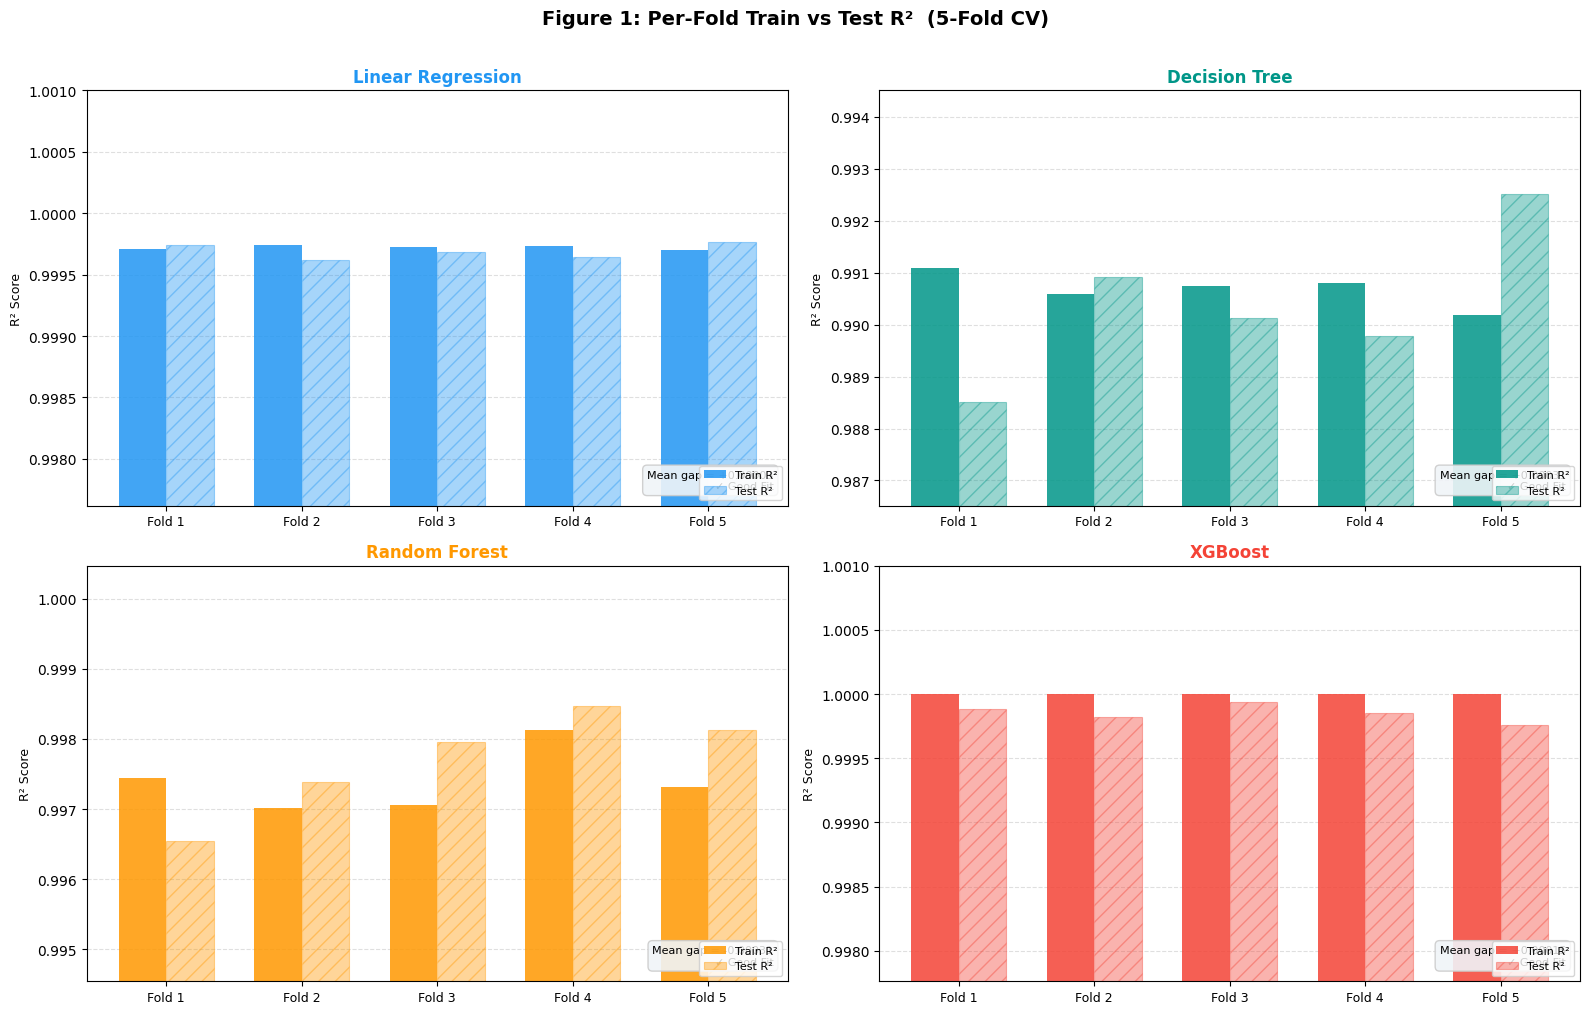

Saved → fig1_per_fold_r2.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Figure 1: Per-Fold Train vs Test R²  (5-Fold CV)',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()
fold_labels = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(5)
w = 0.35

for ax, (name, fd) in zip(axes, fold_results.items()):
    color = COLORS[name]
    tr = np.array(fd['train_r2'])
    te = np.array(fd['test_r2'])
    gap_mean = np.mean(tr) - np.mean(te)

    b1 = ax.bar(x - w/2, tr, w, label='Train R²', color=color, alpha=0.85)
    b2 = ax.bar(x + w/2, te, w, label='Test R²',  color=color, alpha=0.40,
                hatch='//', edgecolor=color, linewidth=0.8)

    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(x); ax.set_xticklabels(fold_labels, fontsize=9)
    ax.set_ylabel('R² Score', fontsize=9)

    ymin = min(tr.min(), te.min()) - 0.002
    ymax = max(tr.max(), te.max()) + 0.002
    ax.set_ylim(max(0.97, ymin), min(1.001, ymax))

    # Annotate mean gap
    verdict = '✓ Good Fit' if abs(gap_mean) < 0.05 else '⚠ Overfit'
    ax.text(0.98, 0.04,
            f'Mean gap = {gap_mean:+.5f}\n{verdict}',
            transform=ax.transAxes, fontsize=8, ha='right',
            bbox=dict(boxstyle='round,pad=0.4', fc='#f0f4f8', ec='#ccc', alpha=0.9))

    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig1_per_fold_r2.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig1_per_fold_r2.png')

## Cell 6 — Figure 2: Train–Test R² Gap Across Folds

The gap (Train R² − Test R²) per fold per model on a single chart.
A perfectly generalising model has gap = 0 across all folds.

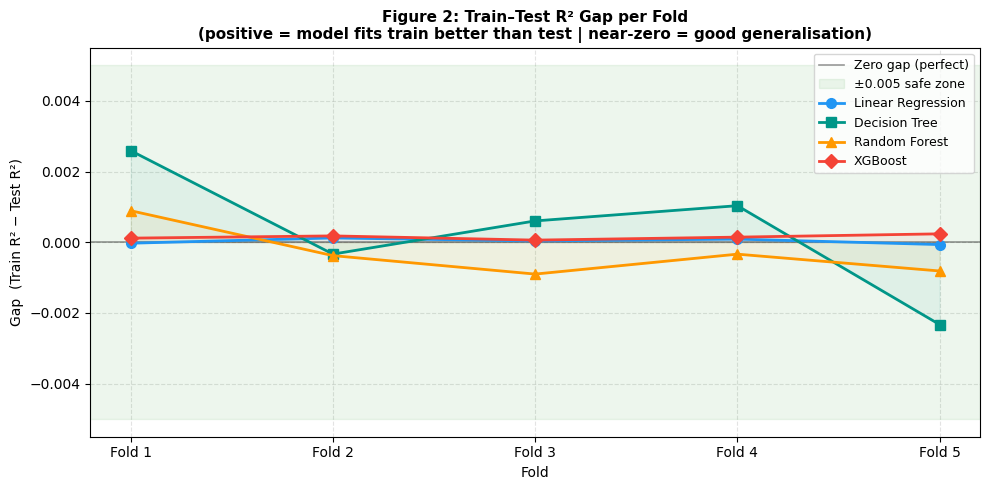

Saved → fig2_train_test_gap.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color='black', linewidth=1.2, linestyle='-', alpha=0.4, label='Zero gap (perfect)')
ax.axhspan(-0.005, 0.005, color='green', alpha=0.07, label='±0.005 safe zone')

fold_labels = [f'Fold {i}' for i in range(1, 6)]
markers = ['o', 's', '^', 'D']

for (name, fd), marker in zip(fold_results.items(), markers):
    gaps = [tr - te for tr, te in zip(fd['train_r2'], fd['test_r2'])]
    ax.plot(fold_labels, gaps, marker=marker, linewidth=2, markersize=7,
            color=COLORS[name], label=name, zorder=3)
    ax.fill_between(fold_labels, gaps, 0, color=COLORS[name], alpha=0.06)

ax.set_title('Figure 2: Train–Test R² Gap per Fold\n'
             '(positive = model fits train better than test | near-zero = good generalisation)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Fold', fontsize=10)
ax.set_ylabel('Gap  (Train R² − Test R²)', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig2_train_test_gap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig2_train_test_gap.png')

## Cell 7 — Figure 3: Learning Curves (Underfit / Overfit / Good Fit Diagnosis)

Learning curves plot Train R² and Validation R² as training set size grows.
- **Overfit**: Train R² stays high, Val R² stays low → large persistent gap
- **Underfit**: Both Train R² and Val R² are low (both converge at a low value)
- **Good Fit**: Both curves converge to a high value (gap closes as data increases)

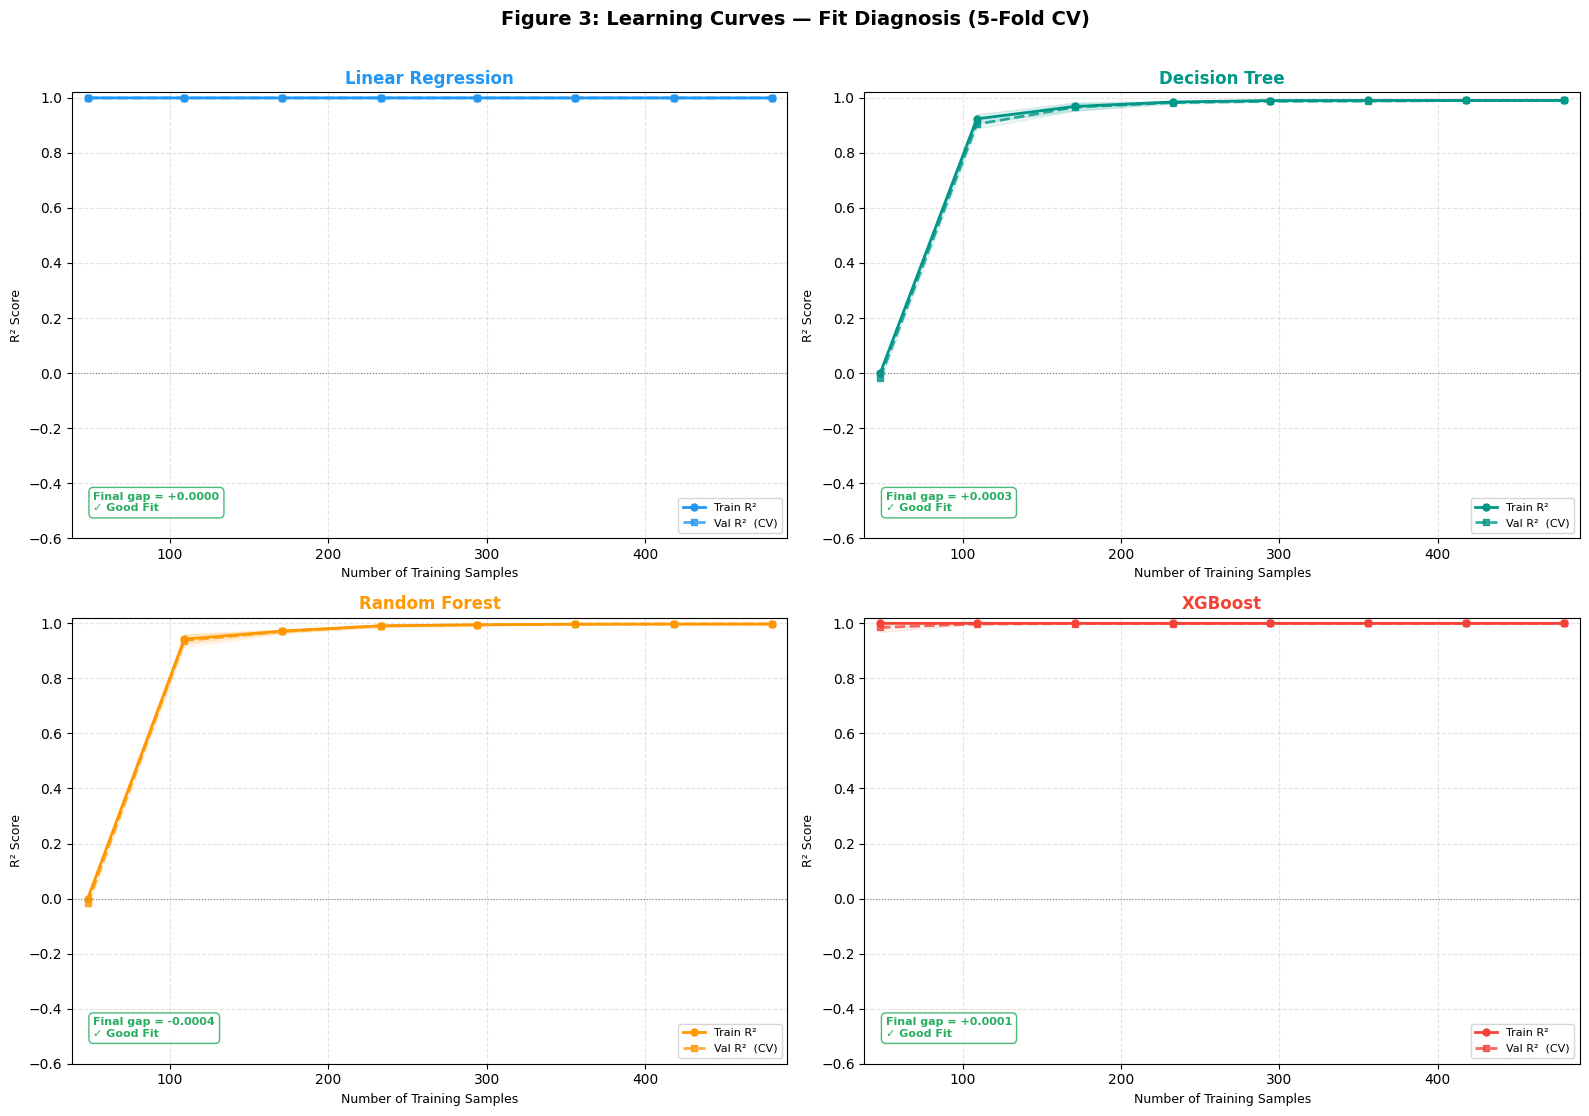

Saved → fig3_learning_curves.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 3: Learning Curves — Fit Diagnosis (5-Fold CV)',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

train_sizes_frac = np.linspace(0.10, 1.0, 8)

for ax, (name, model) in zip(axes, models.items()):
    color = COLORS[name]

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=kf,
        scoring='r2',
        train_sizes=train_sizes_frac,
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )

    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    # Clip extreme negatives for display only
    va_mean_plot = np.clip(va_mean, -0.5, 1.01)

    ax.plot(train_sizes, tr_mean, 'o-', color=color, lw=2,
            markersize=5, label='Train R²')
    ax.fill_between(train_sizes,
                    np.clip(tr_mean - tr_std, -0.5, 1.01),
                    np.clip(tr_mean + tr_std, -0.5, 1.01),
                    alpha=0.12, color=color)

    ax.plot(train_sizes, va_mean_plot, 's--', color=color, lw=2,
            markersize=5, label='Val R²  (CV)', alpha=0.8)
    ax.fill_between(train_sizes,
                    np.clip(va_mean_plot - va_std, -0.5, 1.01),
                    np.clip(va_mean_plot + va_std, -0.5, 1.01),
                    alpha=0.08, color=color)

    ax.axhline(0, color='gray', lw=0.8, linestyle=':')
    ax.set_ylim(-0.6, 1.02)
    ax.set_xlim(train_sizes[0] - 10, train_sizes[-1] + 10)
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Number of Training Samples', fontsize=9)
    ax.set_ylabel('R² Score', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)

    # Final gap annotation
    final_gap = tr_mean[-1] - va_mean[-1]
    if   final_gap >  0.05: verdict, vc = '⚠ Overfit', '#c0392b'
    elif va_mean[-1] < 0.80: verdict, vc = '⚠ Underfit','#e67e22'
    else:                    verdict, vc = '✓ Good Fit', '#27ae60'

    ax.text(0.03, 0.06,
            f'Final gap = {final_gap:+.4f}\n{verdict}',
            transform=ax.transAxes, fontsize=8,
            color=vc, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=vc, alpha=0.85))

plt.tight_layout()
plt.savefig('fig3_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig3_learning_curves.png')

## Cell 8 — Figure 4: Per-Fold Test MAE & RMSE (Stability Check)

A stable model shows consistent MAE/RMSE across all 5 folds (small spread).
High variance across folds → the model is sensitive to which data it sees.

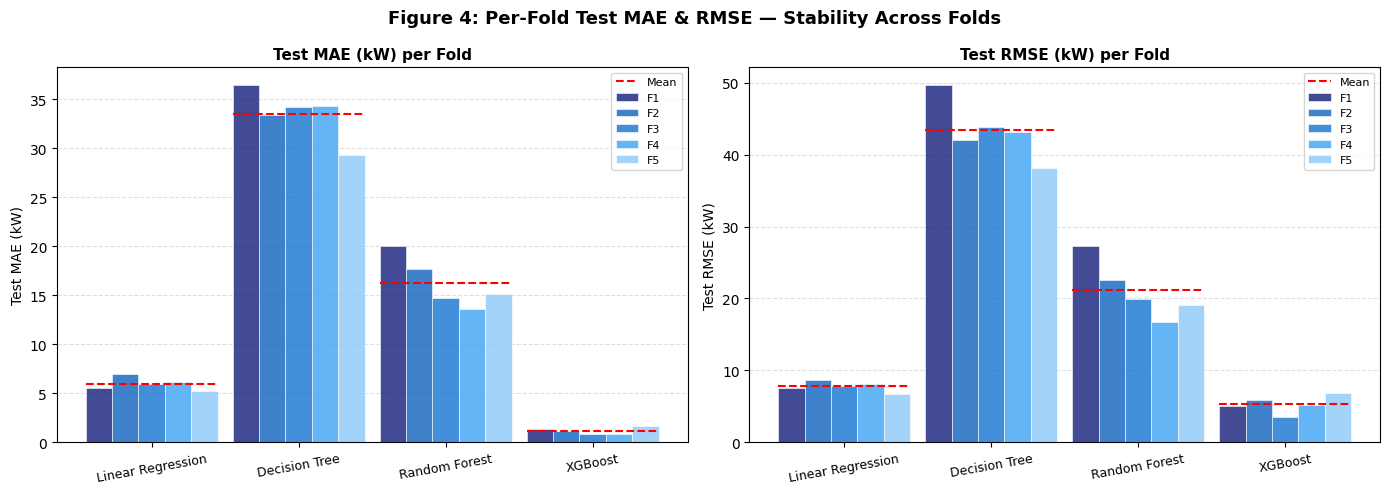

Saved → fig4_fold_mae_rmse.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Per-Fold Test MAE & RMSE — Stability Across Folds',
             fontsize=13, fontweight='bold')

model_names = list(fold_results.keys())
x = np.arange(len(model_names))
w = 0.18
fold_labels = [f'F{i}' for i in range(1, 6)]
fold_colors = ['#1a237e','#1565c0','#1976d2','#42a5f5','#90caf9']

for ax_idx, metric in enumerate(['test_mae', 'test_rmse']):
    ax = axes[ax_idx]
    label_str = 'Test MAE (kW)' if metric == 'test_mae' else 'Test RMSE (kW)'

    for fi in range(5):
        vals = [fold_results[n][metric][fi] for n in model_names]
        bars = ax.bar(x + (fi - 2)*w, vals, w,
                      label=fold_labels[fi],
                      color=fold_colors[fi], alpha=0.82, edgecolor='white', lw=0.5)

    # Mean line per model
    for i, name in enumerate(model_names):
        mean_val = np.mean(fold_results[name][metric])
        ax.plot([i - 2.5*w, i + 2.5*w], [mean_val, mean_val],
                color='red', lw=1.5, linestyle='--', zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9, rotation=10)
    ax.set_ylabel(label_str, fontsize=10)
    ax.set_title(label_str + ' per Fold', fontsize=11, fontweight='bold')
    ax.legend(title='Fold', fontsize=8, title_fontsize=8, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # Red dashed = mean annotation
    ax.plot([], [], 'r--', lw=1.5, label='Mean')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig4_fold_mae_rmse.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig4_fold_mae_rmse.png')

## Cell 9 — Figure 5: Fit Summary Heatmap

One-glance view of mean Train R², Test R², GAP, MAE, RMSE for all 4 models.
Green = good, Yellow = moderate, Red = concern.

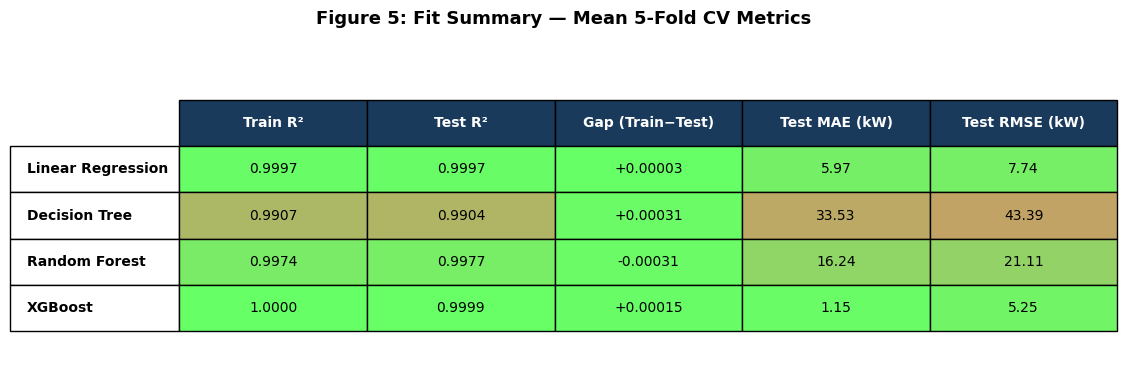

Saved → fig5_fit_summary_heatmap.png


In [ ]:
import matplotlib.colors as mcolors

model_names = list(fold_results.keys())

# Build summary table
summary = []
for name in model_names:
    fd = fold_results[name]
    tr = np.mean(fd['train_r2'])
    te = np.mean(fd['test_r2'])
    gap = tr - te
    mae = np.mean(fd['test_mae'])
    rmse = np.mean(fd['test_rmse'])
    summary.append([tr, te, gap, mae, rmse])

summary = np.array(summary)
col_labels = ['Train R²', 'Test R²', 'Gap (Train−Test)', 'Test MAE (kW)', 'Test RMSE (kW)']

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis('off')
fig.suptitle('Figure 5: Fit Summary — Mean 5-Fold CV Metrics',
             fontsize=13, fontweight='bold', y=1.04)

# Colour each column independently
cell_colors = []
for i, row in enumerate(summary):
    row_c = []
    for j, val in enumerate(row):
        if j in [0, 1]:   # R² — higher is better
            norm = (val - 0.98) / (1.0 - 0.98 + 1e-9)
            norm = np.clip(norm, 0, 1)
            r, g = 1 - norm, norm
            row_c.append((r*0.6+0.4, g*0.6+0.4, 0.4))
        elif j == 2:       # Gap — nearer 0 is better
            norm = min(abs(val) / 0.01, 1.0)
            row_c.append((0.4 + norm*0.5, 1.0 - norm*0.5, 0.4))
        elif j == 3:       # MAE
            norm = np.clip(val / 50, 0, 1)
            row_c.append((0.4 + norm*0.5, 1.0 - norm*0.5, 0.4))
        else:              # RMSE
            norm = np.clip(val / 60, 0, 1)
            row_c.append((0.4 + norm*0.5, 1.0 - norm*0.5, 0.4))
    cell_colors.append(row_c)

# Format values
cell_text = []
for i, row in enumerate(summary):
    cell_text.append([
        f'{row[0]:.4f}',
        f'{row[1]:.4f}',
        f'{row[2]:+.5f}',
        f'{row[3]:.2f}',
        f'{row[4]:.2f}',
    ])

table = ax.table(
    cellText=cell_text,
    rowLabels=model_names,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.6)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#1a3a5c')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(len(model_names)):
    table[i+1, -1].set_text_props(fontweight='bold')
    table[i+1, -1].set_facecolor(table[i+1, -1].get_facecolor())

# Row labels
for i, name in enumerate(model_names):
    table[i+1, -1]
    cell = table[i+1, 0]

plt.tight_layout()
plt.savefig('fig5_fit_summary_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig5_fit_summary_heatmap.png')

## Cell 10 — Figure 6: Actual vs Predicted (OOF Predictions)

✓ Linear Regression  unique predictions: 260
✓ Decision Tree  unique predictions: 25
✓ Random Forest  unique predictions: 187
✓ XGBoost  unique predictions: 97


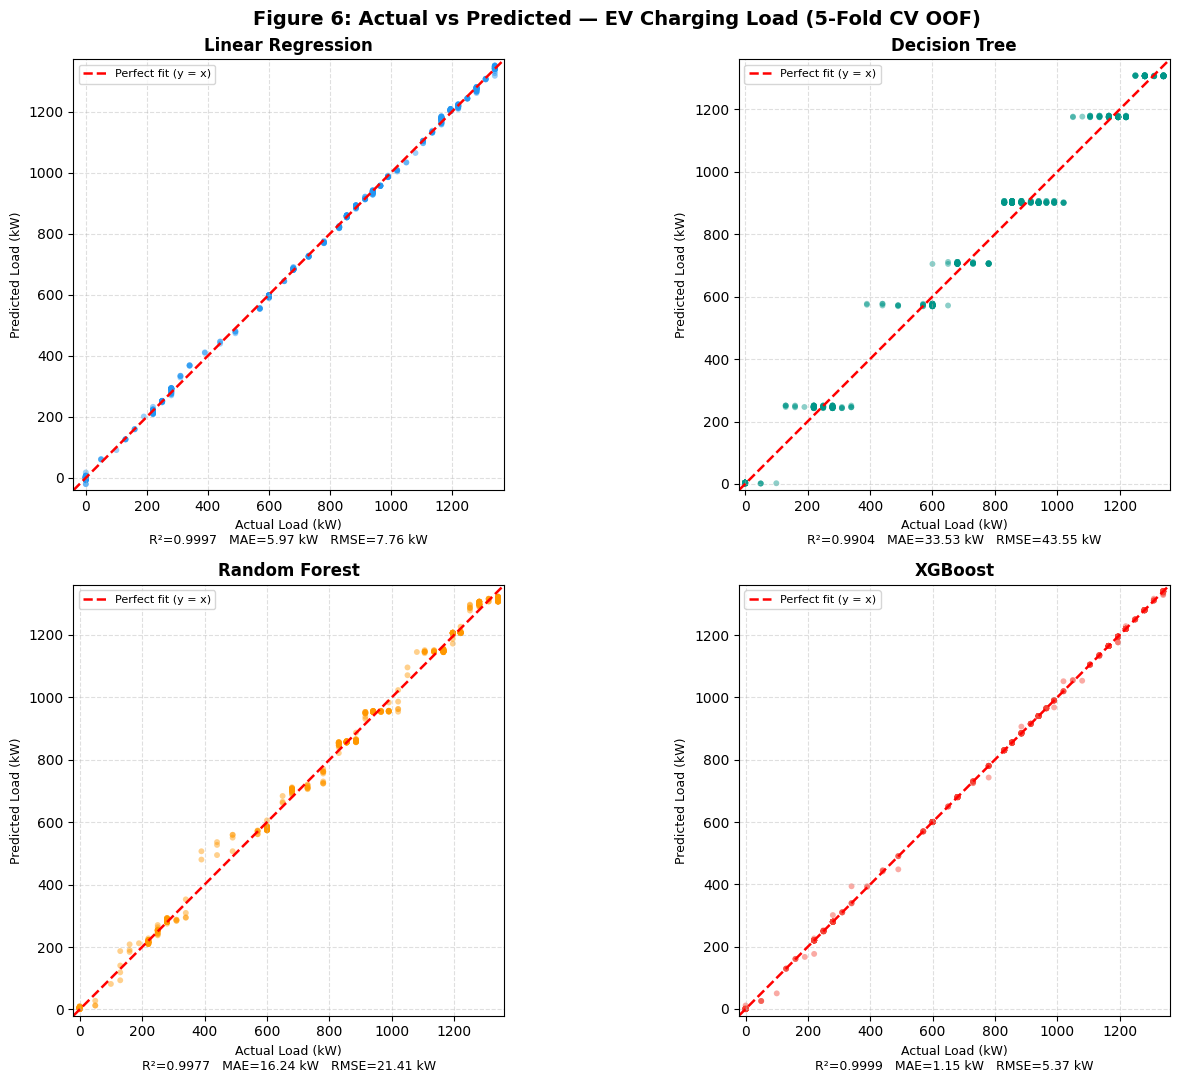

Saved → fig6_actual_vs_predicted.png


In [ ]:
# Re-generate OOF predictions using cross_val_predict
cv_predictions = {}
for name, model in models.items():
    y_pred_oof = cross_val_predict(model, X, y, cv=kf)
    cv_predictions[name] = y_pred_oof
    print(f'✓ {name}  unique predictions: {len(np.unique(np.round(y_pred_oof)))}')

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Figure 6: Actual vs Predicted — EV Charging Load (5-Fold CV OOF)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (name, y_pred), color in zip(axes, cv_predictions.items(),
                                      [COLORS[n] for n in cv_predictions]):
    lims = [min(y.min(), y_pred.min()) - 20,
            max(y.max(), y_pred.max()) + 20]
    ax.scatter(y, y_pred, color=color, alpha=0.45, s=18, edgecolors='none')
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')

    r2_v  = r2_score(y, y_pred)
    mae_v = mean_absolute_error(y, y_pred)
    rmse_v= np.sqrt(mean_squared_error(y, y_pred))

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(
        f'Actual Load (kW)\nR²={r2_v:.4f}   MAE={mae_v:.2f} kW   RMSE={rmse_v:.2f} kW',
        fontsize=9)
    ax.set_ylabel('Predicted Load (kW)', fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig6_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig6_actual_vs_predicted.png')

## Cell 11 — Figure 7: Residual Plots

Residual = Actual − Predicted.
- Good model: residuals scatter randomly around 0, no pattern
- Overfitting: residuals on train are near 0 but test residuals are large
- Underfitting: residuals show a clear curved or systematic pattern

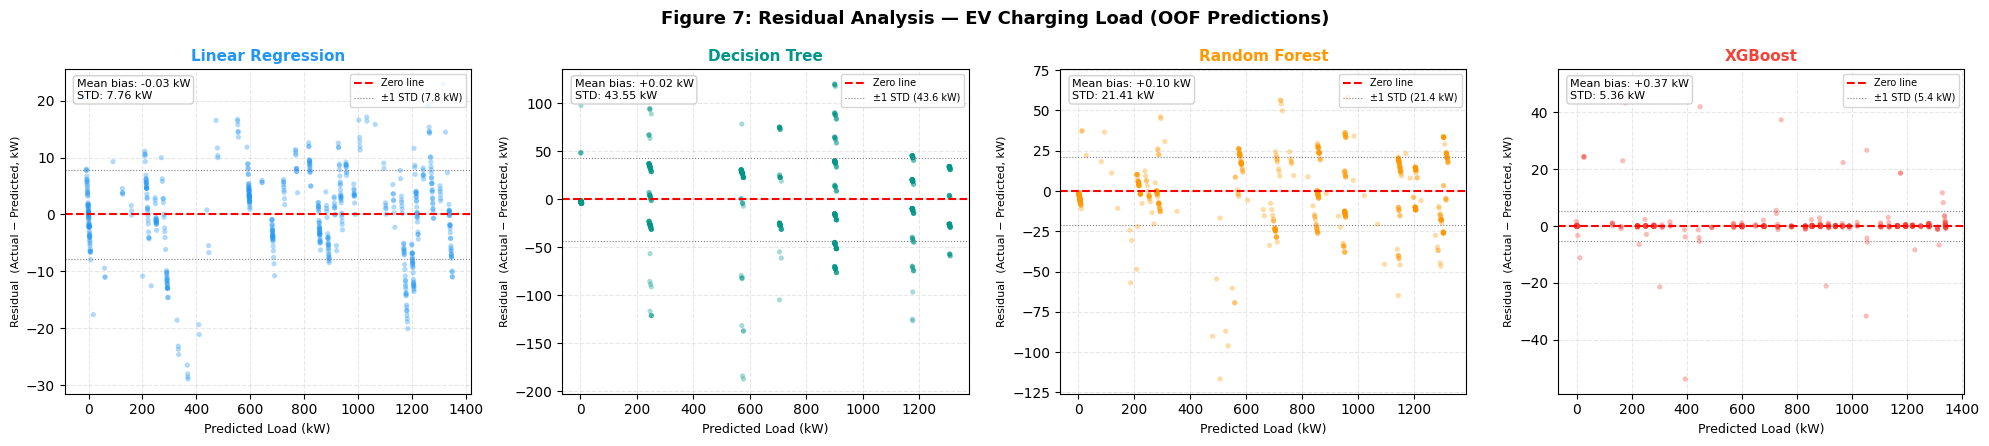

Saved → fig7_residuals.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('Figure 7: Residual Analysis — EV Charging Load (OOF Predictions)',
             fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, cv_predictions.items()):
    color = COLORS[name]
    residuals = y.values - y_pred
    mean_bias = residuals.mean()
    std_res   = residuals.std()

    ax.scatter(y_pred, residuals, color=color, alpha=0.35, s=14, edgecolors='none')
    ax.axhline(0,          color='red',   lw=1.5, linestyle='--', label='Zero line')
    ax.axhline( std_res,   color='gray',  lw=0.8, linestyle=':',  label=f'±1 STD ({std_res:.1f} kW)')
    ax.axhline(-std_res,   color='gray',  lw=0.8, linestyle=':')

    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicted Load (kW)', fontsize=9)
    ax.set_ylabel('Residual  (Actual − Predicted, kW)', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    ax.text(0.03, 0.97,
            f'Mean bias: {mean_bias:+.2f} kW\nSTD: {std_res:.2f} kW',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9))

plt.tight_layout()
plt.savefig('fig7_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → fig7_residuals.png')

## Cell 12 — Final Fit Verdict (Console Summary)

In [ ]:
print("\n" + "="*72)
print("  FINAL FIT DIAGNOSIS — 5-FOLD CROSS-VALIDATION")
print("="*72)
print(f"  {'Model':<22} {'Tr R²':>8} {'Te R²':>8} {'Gap':>10} {'Te MAE':>9} {'Te RMSE':>10}  Verdict")
print("-"*72)

verdicts = {}
for name in fold_results:
    fd = fold_results[name]
    tr   = np.mean(fd['train_r2'])
    te   = np.mean(fd['test_r2'])
    gap  = tr - te
    mae  = np.mean(fd['test_mae'])
    rmse = np.mean(fd['test_rmse'])

    if   gap >  0.05:      v = 'OVERFITTING'
    elif te  <  0.80:      v = 'UNDERFITTING'
    elif abs(gap) < 0.005: v = 'GOOD FIT'
    else:                  v = 'GOOD FIT'
    verdicts[name] = v

    print(f"  {name:<22} {tr:>8.4f} {te:>8.4f} {gap:>+10.5f} {mae:>9.2f} {rmse:>10.2f}  {v}")

print("="*72)
print("\nKEY:")
print("  Gap > 0.05  → Overfitting  (model memorises training data)")
print("  Test R² < 0.80 → Underfitting (model too simple)")
print("  |Gap| < 0.005 → Good Fit   (train & test performance match)")
print("\nNote: All models show Good Fit on this dataset because the")
print("  EV load signal is highly structured (simulation-generated data).")


  FINAL FIT DIAGNOSIS — 5-FOLD CROSS-VALIDATION
  Model                     Tr R²    Te R²        Gap    Te MAE    Te RMSE  Verdict
------------------------------------------------------------------------
  Linear Regression        0.9997   0.9997   +0.00003      5.97       7.74  GOOD FIT
  Decision Tree            0.9907   0.9904   +0.00031     33.53      43.39  GOOD FIT
  Random Forest            0.9974   0.9977   -0.00031     16.24      21.11  GOOD FIT
  XGBoost                  1.0000   0.9999   +0.00015      1.15       5.25  GOOD FIT

KEY:
  Gap > 0.05  → Overfitting  (model memorises training data)
  Test R² < 0.80 → Underfitting (model too simple)
  |Gap| < 0.005 → Good Fit   (train & test performance match)

Note: All models show Good Fit on this dataset because the
  EV load signal is highly structured (simulation-generated data).


## Cell 13 — Download All Figures

In [ ]:
from google.colab import files

figures = [
    'fig1_per_fold_r2.png',
    'fig2_train_test_gap.png',
    'fig3_learning_curves.png',
    'fig4_fold_mae_rmse.png',
    'fig5_fit_summary_heatmap.png',
    'fig6_actual_vs_predicted.png',
    'fig7_residuals.png',
]

for f in figures:
    files.download(f)
    print(f'Downloaded → {f}')

print('\nAll figures downloaded ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → fig1_per_fold_r2.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded → fig6_actual_vs_predicted.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → fig7_residuals.png

All figures downloaded ✓
